In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

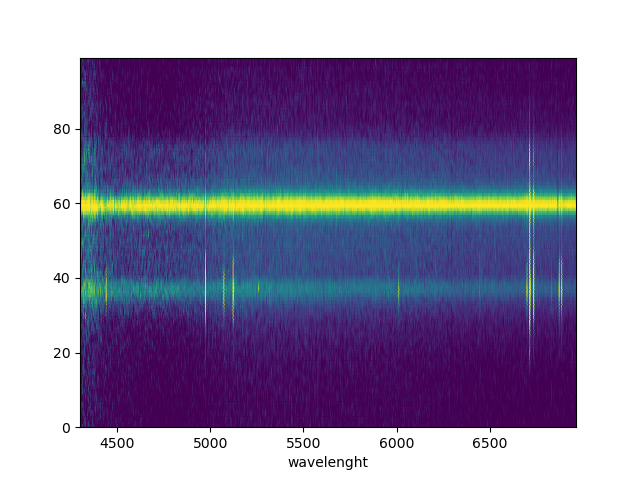

In [5]:
wv = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

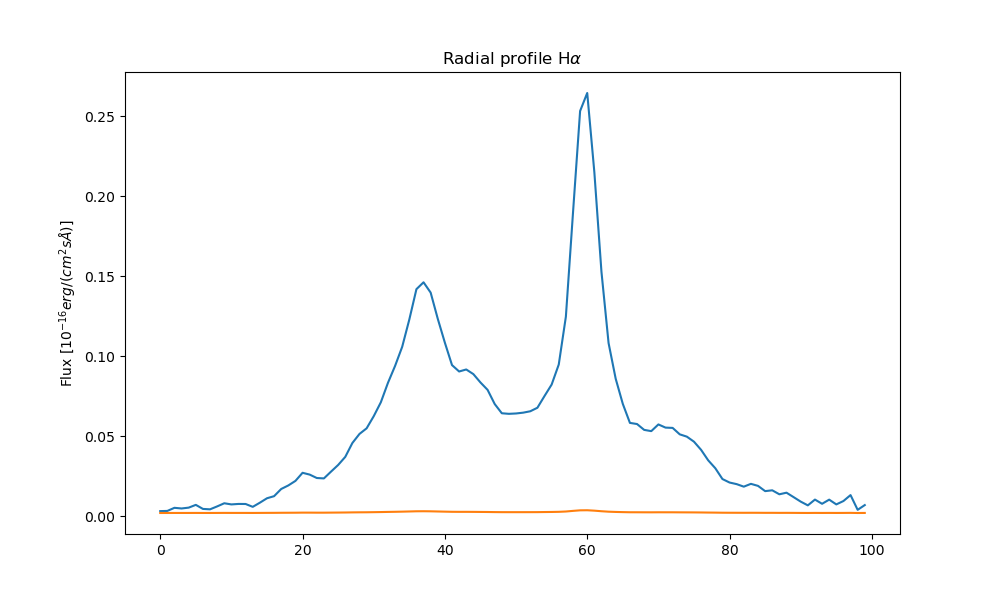

In [7]:
mask_HA = (wv > l_HA-10)*(wv < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
weights_HA = 1/image_error_HA**2
radial_profile_HA, sum_weights_HA = np.average(image_HA, axis = 1, weights = weights_HA, returned = True)
radial_profile_error_HA = 1/np.sqrt(sum_weights_HA)
#radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

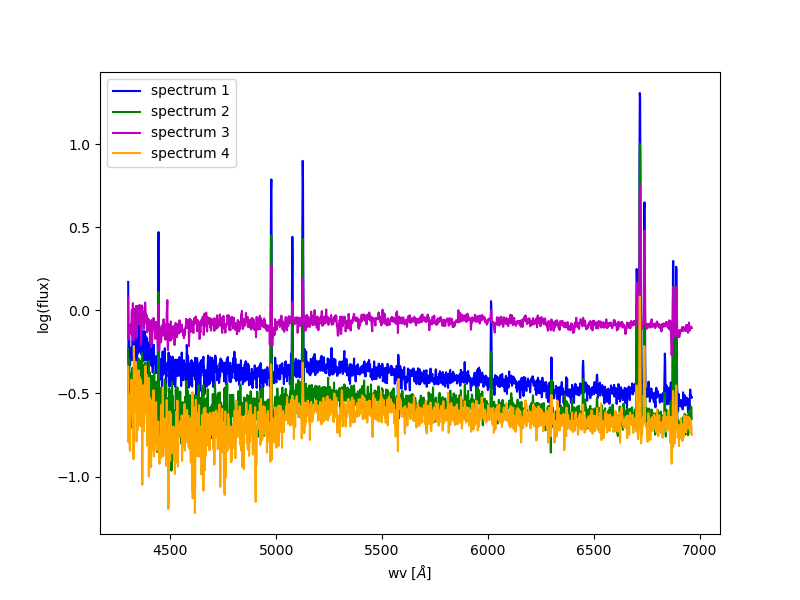

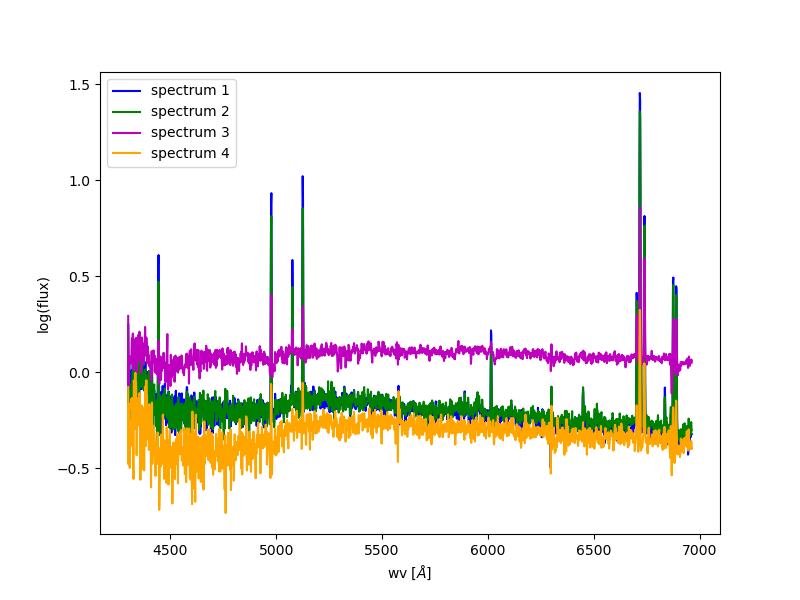

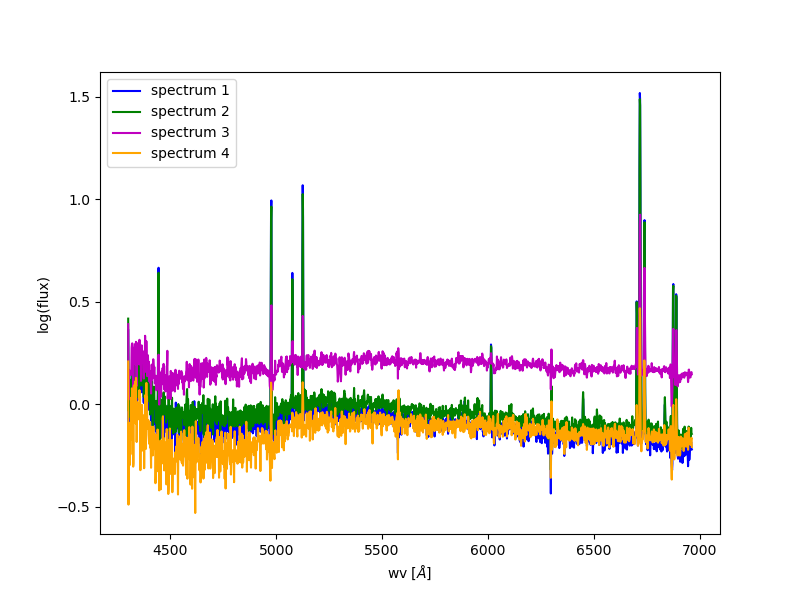

In [8]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv")
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = 3.17 #in pixels
peaks = fit_HA['x_0']

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green', 'm', 'orange']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-seeing)*(x_axes < peaks[i]+seeing)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, np.log10(spectra_1[i]), color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel('log(flux)')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    data1.append(spectrum_table)
    
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_1'), data1[0])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_2'), data1[1])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_3'), data1[2])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_4'), data1[3])

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*seeing)*(x_axes < peaks[i]+2*seeing)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, np.log10(spectra_2[i]), color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel('log(flux)')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    data2.append(spectrum_table)
    
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_1'), data2[0])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_2'), data2[1])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_3'), data2[2])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_4'), data2[3])

plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*seeing)*(x_axes < peaks[i]+3*seeing)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, np.log10(spectra_3[i]), color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel('log(flux)')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    data3.append(spectrum_table)
    
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_1'), data3[0])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_2'), data3[1])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_3'), data3[2])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_4'), data3[3])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [9]:
import pandas as pd

mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_1[i, mask_continuum_1]/spectra_err_1[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_2]/spectra_err_1[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_3]/spectra_err_1[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df.to_csv(df_path, index=False, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_2[i, mask_continuum_1]/spectra_err_2[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_2]/spectra_err_2[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_3]/spectra_err_2[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df.to_csv(df_path, index=False, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_3[i, mask_continuum_1]/spectra_err_3[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_2]/spectra_err_3[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_3]/spectra_err_3[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df.to_csv(df_path, index=False, float_format='%.3f')

                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      8.423826   5.378113  15.821598   4.001664
Continuum_2     13.095925   9.942369  25.585195   8.699428
Continuum_3     13.931211  11.016787  30.198015  10.188823
Mean_Continuum  11.816987   8.779089  23.868269   7.629971
                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      9.158180   9.002304  16.514425   5.735597
Continuum_2     15.399173  15.761307  28.225304  12.816451
Continuum_3     16.483107  17.392218  33.550264  14.983514
Mean_Continuum  13.680153  14.051943  26.096664  11.178521
                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      9.411739  10.552650  16.400339   7.148589
Continuum_2     16.904397  18.704344  29.472656  16.065677
Continuum_3     18.128480  20.565990  35.056595  18.952977
Mean_Continuum  14.814872  16.607661  26.976530  14.055748


## S/N emission lines 

In [10]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [14]:
l_H

4976.6918000000005

In [19]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6675) & (wv < 6695)
    right_region = (wv > 6750) & (wv < 6775)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR

In [20]:
SNR_HB_1 = SNR_line(wv, l_HB, spectra_1, peaks)
np.savetxt(os.path.join('1Sigma', 'SNR_HB_1s'), SNR_HB_1)
SNR_HB_2 = SNR_line(wv, l_HB, spectra_2, peaks)
np.savetxt(os.path.join('2Sigma', 'SNR_HB_2s'), SNR_HB_2)
SNR_HB_3 = SNR_line(wv, l_HB, spectra_3, peaks)
np.savetxt(os.path.join('3Sigma', 'SNR_HB_3s'), SNR_HB_3)

SNR_SII_1 = SNR_line(wv, l_SII, spectra_1, peaks)
np.savetxt(os.path.join('1Sigma', 'SNR_SII_1s'), SNR_SII_1)
SNR_SII_2 = SNR_line(wv, l_SII, spectra_2, peaks)
np.savetxt(os.path.join('2Sigma', 'SNR_SII_2s'), SNR_SII_2)
SNR_SII_3 = SNR_line(wv, l_SII, spectra_3, peaks)
np.savetxt(os.path.join('3Sigma', 'SNR_SII_3s'), SNR_SII_3)

SNR_OIII_1 = SNR_line(wv, l_OIII, spectra_1, peaks)
np.savetxt(os.path.join('1Sigma', 'SNR_OIII_1s'), SNR_OIII_1)
SNR_OIII_2 = SNR_line(wv, l_OIII, spectra_2, peaks)
np.savetxt(os.path.join('2Sigma', 'SNR_OIII_2s'), SNR_OIII_2)
SNR_OIII_3 = SNR_line(wv, l_OIII, spectra_3, peaks)
np.savetxt(os.path.join('3Sigma', 'SNR_OIII_3s'), SNR_OIII_3)

SNR_HA_1 = SNR_HA_NII(wv, l_HA, spectra_1, peaks)
np.savetxt(os.path.join('1Sigma', 'SNR_HA_1s'), SNR_HA_1)
SNR_HA_2 = SNR_HA_NII(wv, l_HA, spectra_2, peaks)
np.savetxt(os.path.join('2Sigma', 'SNR_HA_2s'), SNR_HA_2)
SNR_HA_3 = SNR_HA_NII(wv, l_HA, spectra_3, peaks)
np.savetxt(os.path.join('3Sigma', 'SNR_HA_3s'), SNR_HA_3)

SNR_NII_1 = SNR_HA_NII(wv, l_NII, spectra_1, peaks)
np.savetxt(os.path.join('1Sigma', 'SNR_NII_1s'), SNR_NII_1)
SNR_NII_2 = SNR_HA_NII(wv, l_NII, spectra_2, peaks)
np.savetxt(os.path.join('2Sigma', 'SNR_NII_2s'), SNR_NII_2)
SNR_NII_3 = SNR_HA_NII(wv, l_NII, spectra_3, peaks)
np.savetxt(os.path.join('3Sigma', 'SNR_NII_3s'), SNR_NII_3)

In [22]:
left_region_HA = (wv > 6675) & (wv < 6695)
right_region_HA = (wv > 6750) & (wv < 6775)
clean_mask_HA = left_region_HA | right_region_HA #But also for the two NII lines bc they are closed

mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
wv_bin_HA = np.array(np.where(mask_HA == True))
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
wv_bin_NII = np.array(np.where(mask_NII == True))

signal_HA_1s = []
noise_HA_1s = []
SNR_HA_1s = []
signal_NII_1s = []
noise_NII_1s = []
SNR_NII_1s = []
for i in range(len(peaks)):
    flux_HA = spectra_1[i, mask_HA] - np.mean(spectra_1[i, clean_mask_HA])
    signal = (np.trapz(flux_HA, wv[mask_HA]))
    noise = np.std(spectra_1[i, clean_mask_HA] - np.mean(spectra_1[i, clean_mask_HA]))*1.48*np.sqrt(wv_bin_HA.shape[1]) #std*delta(wv)*number of A under the line
    SNR_HA_1s.append(signal/noise)
    signal_HA_1s.append(signal)
    noise_HA_1s.append(noise)

print(signal_HA_1s)
print(noise_HA_1s)
print(SNR_HA_1s)


[80.46573824681452, 39.50037539689567, 18.781128307178044, 3.8191294755527037]
[0.09930448036488462, 0.07687149045738007, 0.12173508344747723, 0.10454412346582376]
[810.2931302913123, 513.8494799810849, 154.27868265503912, 36.5312687977264]


In [12]:
a =np.array(np.where(mask_HA == True))
a.shape[1]

11

In [13]:
np.where(mask_HA == True)

(array([1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639],
       dtype=int64),)